IMPORT LIBRARIES

In [10]:
import warnings
import sqlite3

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings("ignore")

CONNECT TO DATABASE

In [5]:
conn = sqlite3.connect("inventory.db")

LOAD VENDOR PERFORMANCE DATA

In [6]:
df = pd.read_sql_query(
    """
    SELECT *
    FROM vendor_sales_summary
    """,
    conn
)

display(df.head())

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


BASIC DATASET OVERVIEW

In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

Shape: (10648, 18)

Columns:
['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice', 'ActualPrice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnOver', 'SalesToPurchaseRatio']

Data Types:


VendorNumber               int64
VendorName                   str
Brand                      int64
Description                  str
PurchasePrice            float64
ActualPrice              float64
Volume                   float64
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity         int64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
GrossProfit              float64
ProfitMargin             float64
StockTurnOver            float64
SalesToPurchaseRatio     float64
dtype: object


Missing Values:


VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalSalesPrice          0
TotalExciseTax           0
FreightCost              0
GrossProfit              0
ProfitMargin             0
StockTurnOver            0
SalesToPurchaseRatio     0
dtype: int64

## Exploratory Data Analysis

* **Database Review:** We examined the database tables to identify key variables, understand their relationships, and select the relevant data for analysis.
* **EDA:** We will now analyze the final dataset to understand column distributions, identify patterns and anomalies, and assess data quality before further analysis.


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,1.064071e+04,18700.404409,2.00,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,1.805450e+04,12643.196784,58.00,5816.500000,18776.500000,25521.250000,9.063100e+04
PurchasePrice,10648.0,2.440210e+01,109.483355,0.36,6.840000,10.450000,19.470000,5.681810e+03
ActualPrice,10648.0,3.567118e+01,148.534066,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10648.0,8.478839e+02,665.354152,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10648.0,3.145160e+03,11113.367455,1.00,36.000000,261.000000,1981.250000,3.376600e+05
TotalPurchaseDollars,10648.0,3.013816e+04,123277.154715,0.71,452.857500,3646.725000,20764.170000,3.811252e+06
TotalSalesQuantity,10648.0,3.081902e+03,10971.073340,0.00,33.000000,260.500000,1934.250000,3.349390e+05
TotalSalesDollars,10648.0,4.230292e+04,167947.264974,0.00,728.275000,5285.915000,28414.050000,5.101920e+06
TotalSalesPrice,10648.0,1.881365e+04,45018.406384,0.00,288.830000,2841.775000,16080.270000,6.728193e+05


Numerical Feature Distributions

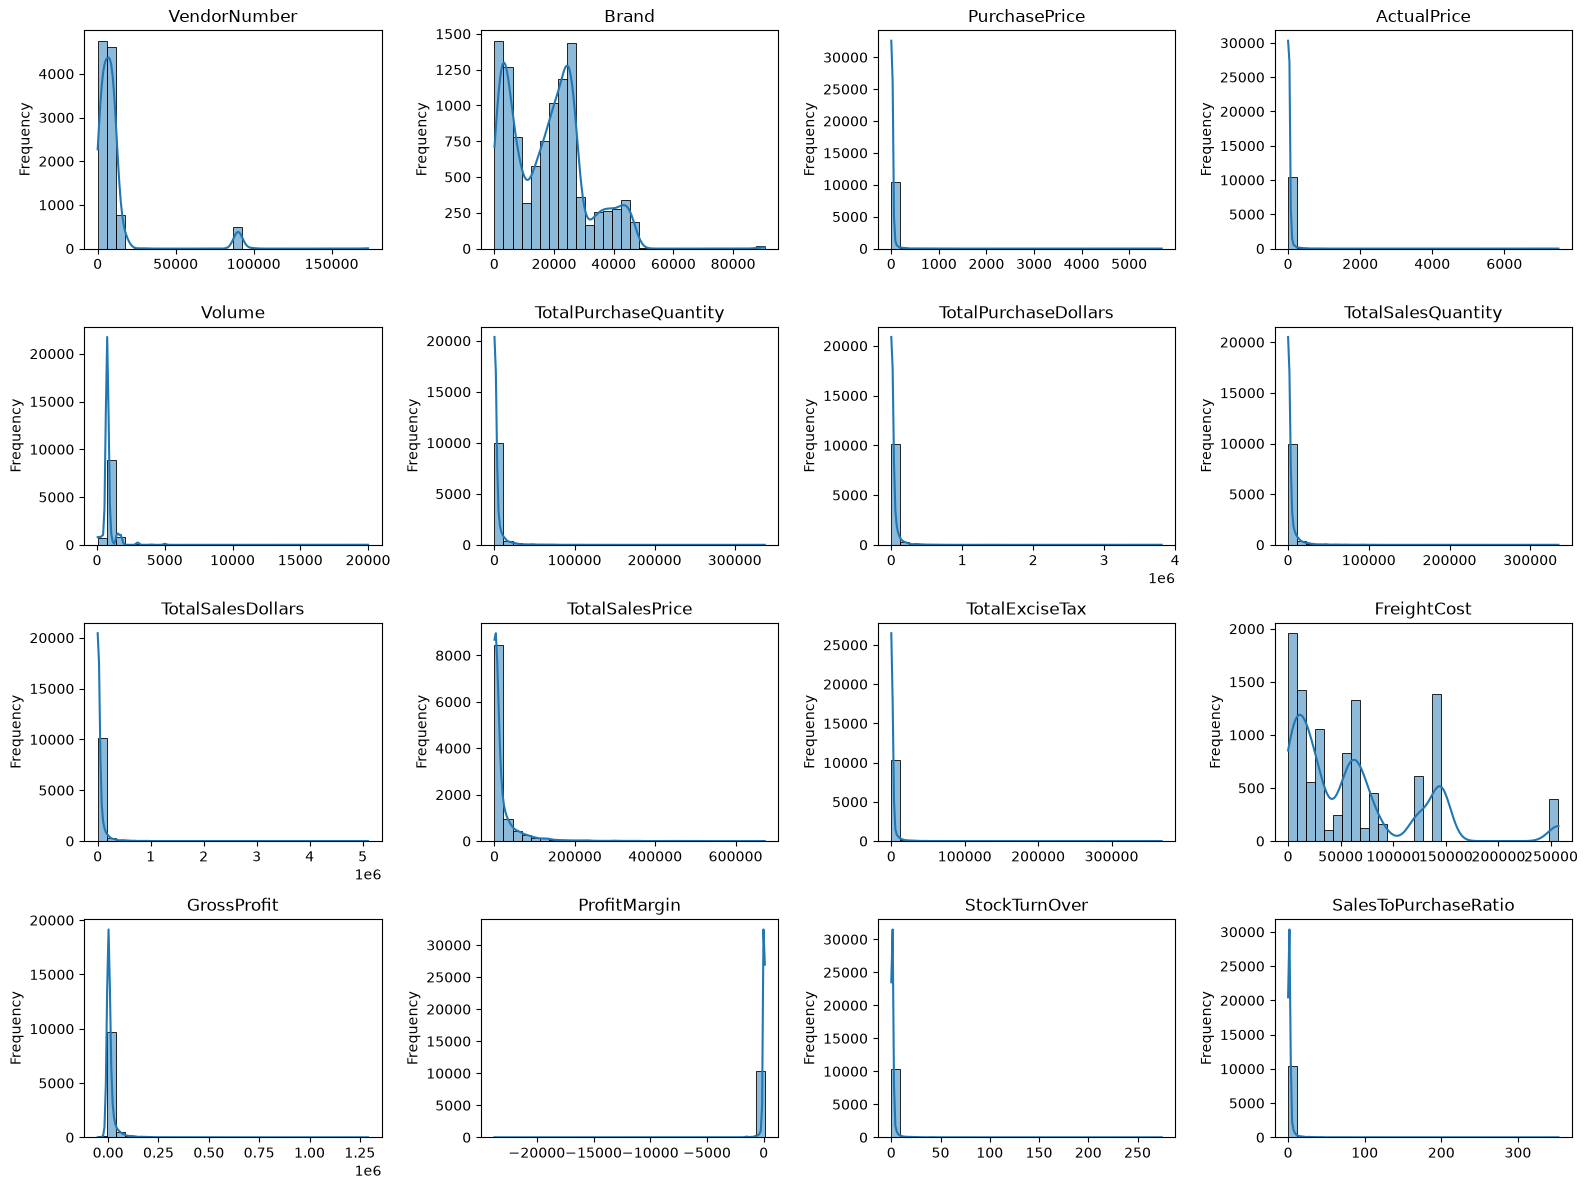

In [11]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Create subplot grid
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(16, 12)
)

axes = axes.flatten()

# Plot distributions
for i, col in enumerate(numerical_cols):

    sns.histplot(
        df[col].replace([np.inf, -np.inf], np.nan).dropna(),
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Boxplots — Numerical Features

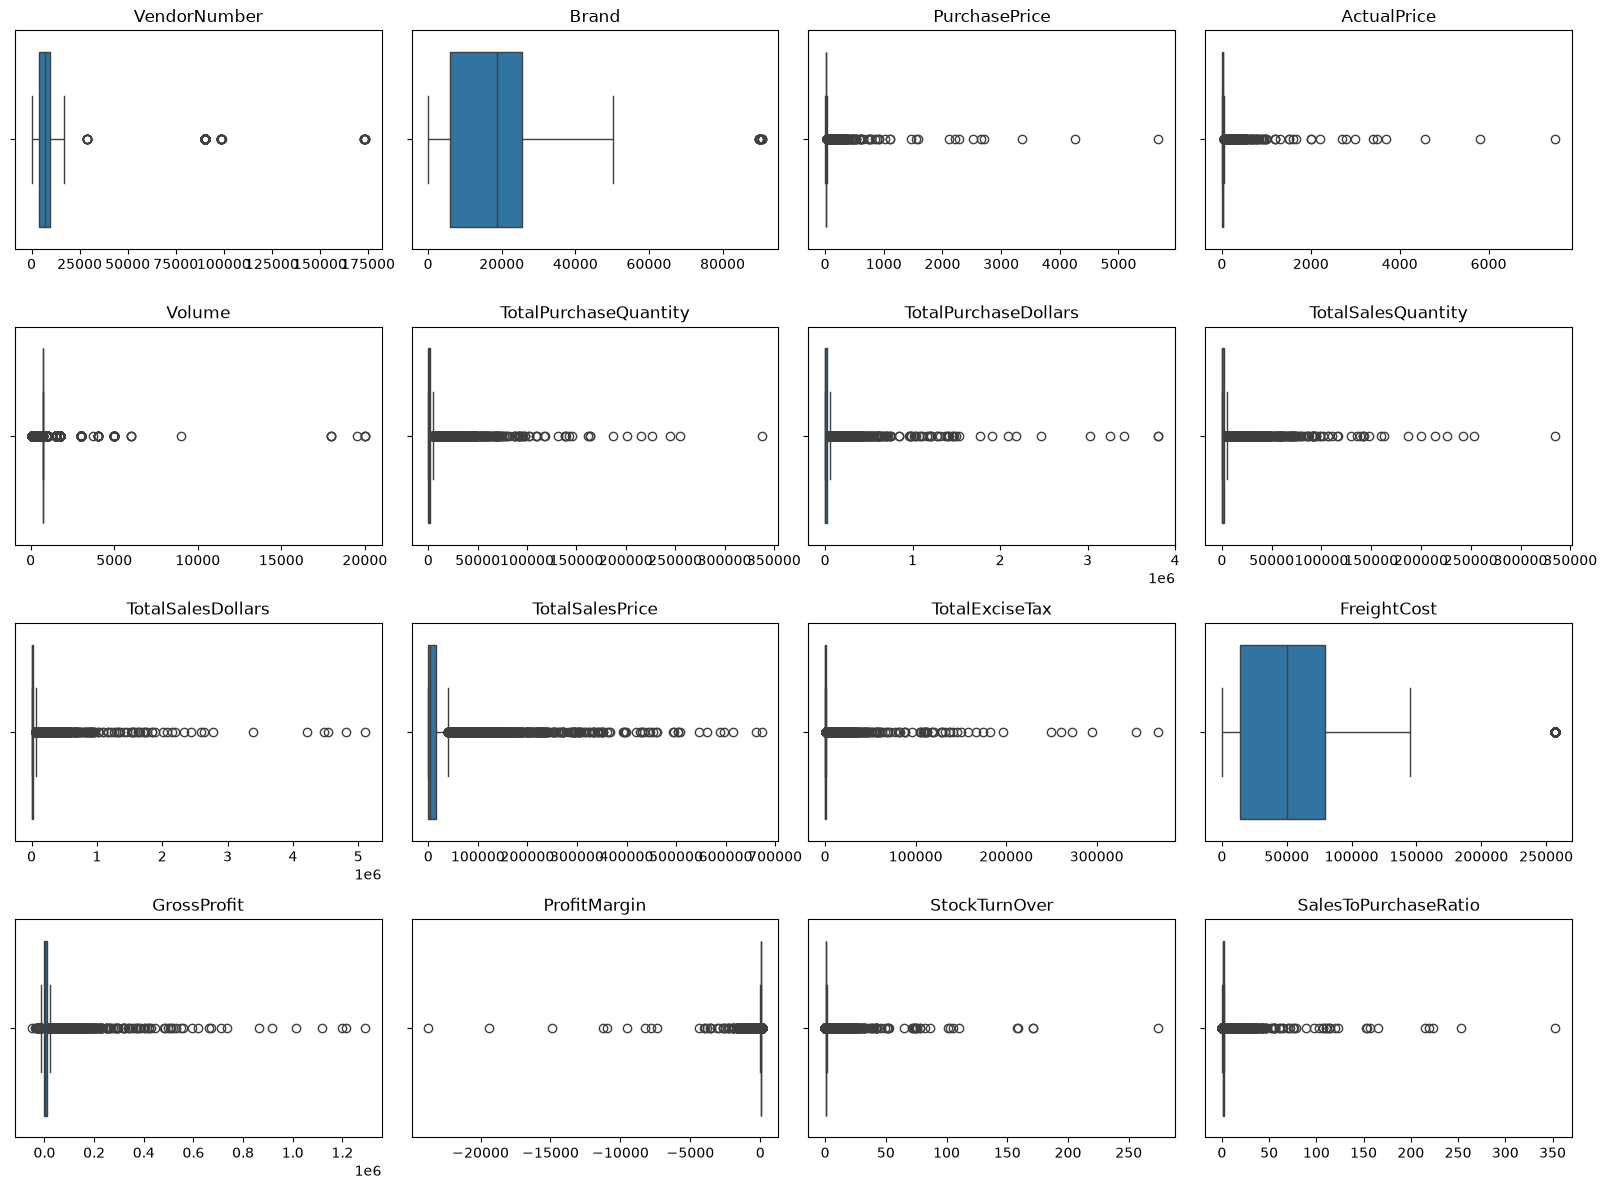

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df[col].replace([np.inf, -np.inf], np.nan),
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()